In [1]:
# 📦 Basic libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔄 Progress bar and system tools
from tqdm import tqdm  # For tracking progress in loops
import sys             # For system-level operations (e.g., flushing output)

# ⚖️ Resampling techniques from imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, BorderlineSMOTE  # Over-sampling methods
from imblearn.under_sampling import RandomUnderSampler, NearMiss, ClusterCentroids, TomekLinks  # Under-sampling methods

# 🧪 Model preparation
from sklearn.model_selection import train_test_split       # For splitting dataset
from sklearn.preprocessing import StandardScaler           # For feature scaling
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # For evaluation

# 🤖 Classification models
from sklearn.linear_model import LogisticRegression        # Logistic Regression
from sklearn.tree import DecisionTreeClassifier            # Decision Tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier  # Tree ensembles
from sklearn.neighbors import KNeighborsClassifier         # K-Nearest Neighbors
from sklearn.naive_bayes import GaussianNB                 # Naive Bayes

# ⚡ Advanced boosting models
from xgboost import XGBClassifier                          # XGBoost
from lightgbm import LGBMClassifier                        # LightGBM
from catboost import CatBoostClassifier                    # CatBoost

churn_data = pd.read_csv('telco_churn_data.csv')

In [2]:
# class distribution
class_distribution = churn_data['Customer Status'].value_counts().reset_index()
class_distribution.columns = ['Customer Status', 'Count']

# Calculate the percentage of each class
class_distribution['Percentage'] = (class_distribution['Count'] / class_distribution['Count'].sum()) * 100

# Display the table
print(class_distribution)

   Customer Status  Count  Percentage
0                1   4720   67.016896
1                2   1869   26.536987
2                0    454    6.446117


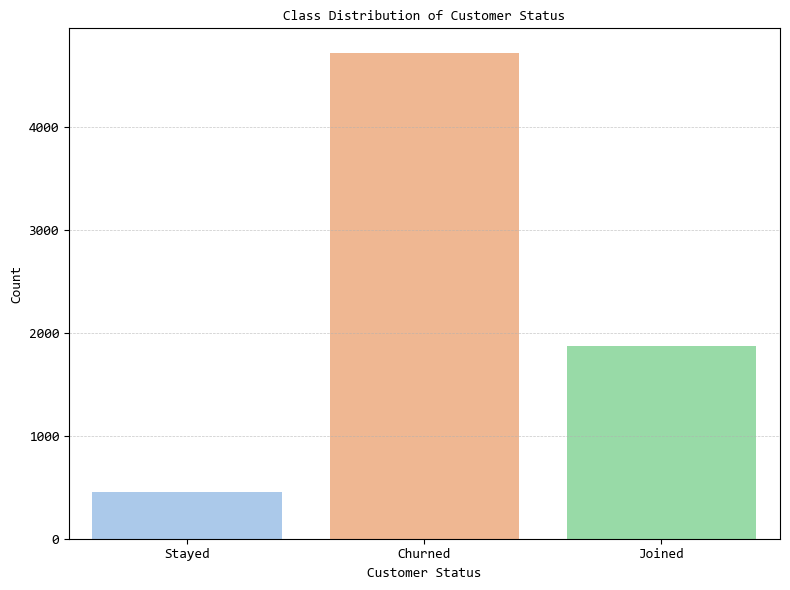

In [3]:
# Plotting the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Status', data=churn_data, hue='Customer Status', palette='pastel', legend=False)
plt.title('Class Distribution of Customer Status', fontsize=10, fontname='Consolas')
plt.xlabel('Customer Status', fontsize=10, fontname='Consolas')
plt.ylabel('Count', fontsize=10, fontname='Consolas')

plt.xticks(ticks=[0, 1, 2], labels=['Stayed', 'Churned', 'Joined'], fontsize=10, fontname='Consolas')
plt.yticks(fontsize=10, fontname='Consolas')

plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [4]:
# feature and target definition
X = churn_data.drop('Customer Status', axis=1)
y = churn_data['Customer Status']

# split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scaled data to df to have feature names retained
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [5]:
# Resampling techniques
resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'TomekLinks': TomekLinks(),
}

# Models with proper settings
models = {
    'LogisticRegression': LogisticRegression(solver='saga', max_iter=2000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),  
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)  
}

In [6]:
# Prepare balanced datasets with detailed progress and logging
balanced_data = {}
print("⚙️ Preparing balanced datasets...\n")

# Initialize progress bar
for name, sampler in tqdm(resamplers.items(), desc="Balancing Techniques", unit="technique", total=len(resamplers)):
    sys.stdout.write(f"\r🔄 Applying: {name}...") 
    sys.stdout.flush()  
    X_res, y_res = sampler.fit_resample(X_train_scaled_df, y_train)
    balanced_data[name] = (X_res, y_res)

print("\n✅ Balanced datasets ready.")

⚙️ Preparing balanced datasets...



Balancing Techniques:   0%|          | 0/6 [00:00<?, ?technique/s]

🔄 Applying: SMOTE...

Balancing Techniques:  17%|█▋        | 1/6 [00:00<00:00,  5.24technique/s]

🔄 Applying: BorderlineSMOTE.....

Balancing Techniques:  67%|██████▋   | 4/6 [00:00<00:00, 14.96technique/s]

🔄 Applying: TomekLinks...mpler...

Balancing Techniques: 100%|██████████| 6/6 [00:00<00:00, 15.31technique/s]


✅ Balanced datasets ready.


In [7]:
results = []

# Evaluation
print("🔍 Starting model evaluation on all balanced datasets...\n")

for technique_name, (X_bal, y_bal) in balanced_data.items():
    print(f"\n📊 Evaluating Models for: {technique_name}\n{'-'*50}")
    for model_name, model in models.items():
        print(f"\n➡️ Training model: {model_name}")
        model.fit(X_bal, y_bal)
        y_pred = model.predict(X_test_scaled_df)
        
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0) # change zero_division

        # Metrics for class 0 and class 1
        precision_0 = report['0']['precision']
        recall_0 = report['0']['recall']
        f1_0 = report['0']['f1-score']

        precision_1 = report['1']['precision']
        recall_1 = report['1']['recall']
        f1_1 = report['1']['f1-score']

        results.append({
            'Technique': technique_name,
            'Model': model_name,
            'Accuracy': acc,
            'Precision_0': precision_0,
            'Recall_0': recall_0,
            'F1_0': f1_0,
            'Precision_1': precision_1,
            'Recall_1': recall_1,
            'F1_1': f1_1
        })

        # Print as usual
        print(f"✅ Accuracy: {acc:.4f}")
        print(f"\n📝 Classification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, zero_division=0)) # change zero_division
        cm = confusion_matrix(y_test, y_pred)
        cm_df = pd.DataFrame(cm, index=['True Stayed', 'True Churned', 'True Joined'], columns=['Predicted Stayed', 'Predicted Churned', 'Predicted Joined'])
        print(f"\n🔢 Confusion Matrix for {model_name} ({technique_name}):")
        print(cm_df)

print("\n✅ All model evaluations complete.")

🔍 Starting model evaluation on all balanced datasets...


📊 Evaluating Models for: SMOTE
--------------------------------------------------

➡️ Training model: LogisticRegression
✅ Accuracy: 0.7610

📝 Classification Report for LogisticRegression:

              precision    recall  f1-score   support

           0       0.45      0.90      0.60       136
           1       0.93      0.79      0.86      1416
           2       0.57      0.65      0.61       561

    accuracy                           0.76      2113
   macro avg       0.65      0.78      0.69      2113
weighted avg       0.80      0.76      0.77      2113


🔢 Confusion Matrix for LogisticRegression (SMOTE):
              Predicted Stayed  Predicted Churned  Predicted Joined
True Stayed                123                  0                13
True Churned                36               1122               258
True Joined                112                 86               363

➡️ Training model: DecisionTree
✅ Accuracy: 0.